## 1. Install Dependencies

In [ ]:
!python -m pip install facenet-pytorch opencv-python-headless torch torchvision Pillow scikit-learn tqdm matplotlib fastapi uvicorn python-multipart nest-asyncio

'pip' is not recognized as an internal or external command,
operable program or batch file.


## 2. Imports

In [2]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.model_selection import train_test_split
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

c:\Users\meenu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 3. Configuration

In [ ]:

CONFIG = {
    "data_dir"       : "./lfw_dataset",   # Path to your face dataset
    "model_save_path": "./face_auth_model.pth",
    "embedding_dim"  : 512,
    "batch_size"     : 32,
    "num_epochs"     : 20,
    "learning_rate"  : 1e-4,
    "triplet_margin" : 0.5,
    "image_size"     : 160,     # FaceNet expects 160x160
    "min_images"     : 2,       # Minimum images per identity for triplet mining
    "pretrained"     : "vggface2",  # or 'casia-webface'
}
print("Configuration loaded:", CONFIG)

Configuration loaded: {'data_dir': './lfw_dataset', 'model_save_path': './face_auth_model.pth', 'embedding_dim': 512, 'batch_size': 32, 'num_epochs': 20, 'learning_rate': 0.0001, 'triplet_margin': 0.5, 'image_size': 160, 'min_images': 2, 'pretrained': 'vggface2'}


## 4. Dataset Setup

Synthetic dataset already exists at './synthetic_faces' (300 images). Skipping.
Using synthetic dataset at: ./synthetic_faces


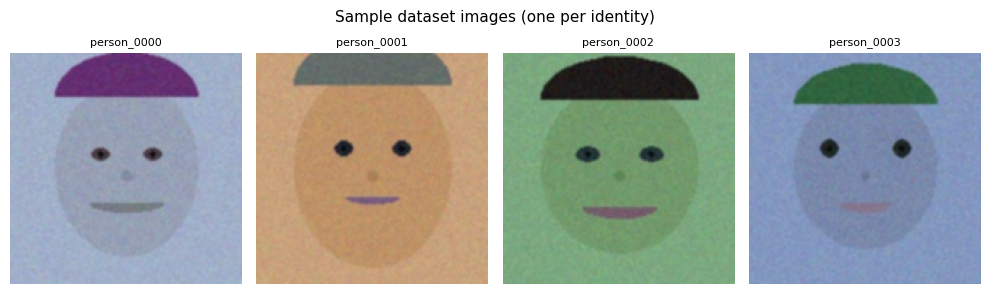

In [ ]:

USE_OWN_DATASET  = False            # ← set True to use your own images
OWN_DATASET_PATH = "./my_faces"     # ← path to your dataset folder


SYNTH_DIR        = "./synthetic_faces"
NUM_IDENTITIES   = 50               # identities to generate
IMGS_PER_PERSON  = 6                # images per identity


def _make_synthetic_face(identity_seed: int, img_idx: int, size: int = 160) -> np.ndarray:
    """
    Create a deterministic, identity-specific synthetic face image using
    NumPy + OpenCV only — no internet required.
    Each identity has a unique base colour, oval head shape, and landmark
    pattern; img_idx adds controlled noise so images of the same identity
    look similar but not identical.
    """
    rng   = np.random.default_rng(identity_seed * 1000)          # identity RNG
    noise_rng = np.random.default_rng(identity_seed * 1000 + img_idx)

    # Background skin tone (identity-specific)
    base_color = rng.integers(100, 220, size=3).tolist()          # BGR
    img = np.full((size, size, 3), base_color, dtype=np.uint8)

    cx, cy = size // 2, size // 2

    # Head oval
    head_rx = int(rng.integers(45, 60))
    head_ry = int(rng.integers(55, 72))
    head_color = (int(base_color[0]-20), int(base_color[1]-15), int(base_color[2]-10))
    cv2.ellipse(img, (cx, cy), (head_rx, head_ry), 0, 0, 360, head_color, -1)

    # Eyes
    eye_y  = cy - int(rng.integers(10, 20))
    eye_dx = int(rng.integers(18, 28))
    eye_rx, eye_ry = int(rng.integers(6, 10)), int(rng.integers(4, 7))
    eye_color = tuple(rng.integers(20, 80, size=3).tolist())
    for ex in [cx - eye_dx, cx + eye_dx]:
        cv2.ellipse(img, (ex, eye_y), (eye_rx, eye_ry), 0, 0, 360, eye_color, -1)
        # Pupil
        cv2.circle(img, (ex, eye_y), max(2, eye_rx//3), (10, 10, 10), -1)

    # Nose (small dot)
    nose_color = tuple((np.array(head_color) - 20).clip(0, 255).tolist())
    cv2.circle(img, (cx, cy + 5), int(rng.integers(3, 6)), nose_color, -1)

    # Mouth
    mouth_y   = cy + int(rng.integers(18, 28))
    mouth_w   = int(rng.integers(16, 26))
    mouth_col = tuple(rng.integers(80, 150, size=3).tolist())
    cv2.ellipse(img, (cx, mouth_y), (mouth_w, int(rng.integers(4, 8))),
                0, 0, 180, mouth_col, -1)

    # Hair (top band)
    hair_color = tuple(rng.integers(20, 120, size=3).tolist())
    cv2.ellipse(img, (cx, cy - head_ry + 10), (head_rx, head_ry // 2),
                0, 180, 360, hair_color, -1)

    # Per-image noise (simulates lighting / pose variation)
    noise = noise_rng.integers(-18, 18, img.shape, dtype=np.int16)
    img   = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    # Slight blur for realism
    img = cv2.GaussianBlur(img, (3, 3), 0)
    return img


def build_synthetic_dataset(out_dir: str, n_identities: int, imgs_per_person: int):
    """Generate synthetic face images in the expected folder structure."""
    if os.path.exists(out_dir):
        existing = sum(len(f) for _, _, f in os.walk(out_dir))
        if existing >= n_identities * imgs_per_person:
            print(f"Synthetic dataset already exists at '{out_dir}' ({existing} images). Skipping.")
            return

    print(f"Generating synthetic dataset: {n_identities} identities × {imgs_per_person} images …")
    os.makedirs(out_dir, exist_ok=True)

    for pid in range(n_identities):
        person_dir = os.path.join(out_dir, f"person_{pid:04d}")
        os.makedirs(person_dir, exist_ok=True)
        for iid in range(imgs_per_person):
            face = _make_synthetic_face(identity_seed=pid, img_idx=iid)
            cv2.imwrite(os.path.join(person_dir, f"img_{iid:03d}.jpg"), face)

    total = n_identities * imgs_per_person
    print(f"Done — {total} images written to '{out_dir}'")


# Select dataset path 
if USE_OWN_DATASET:
    if not os.path.isdir(OWN_DATASET_PATH):
        raise FileNotFoundError(
            f"Dataset folder not found: '{OWN_DATASET_PATH}'.\n"
            "Please set OWN_DATASET_PATH to a valid directory, or set "
            "USE_OWN_DATASET = False to use the synthetic dataset."
        )
    CONFIG["data_dir"] = OWN_DATASET_PATH
    print(f"Using your dataset at: {OWN_DATASET_PATH}")
else:
    build_synthetic_dataset(SYNTH_DIR, NUM_IDENTITIES, IMGS_PER_PERSON)
    CONFIG["data_dir"] = SYNTH_DIR
    print(f"Using synthetic dataset at: {SYNTH_DIR}")

# Preview a few generated faces 
sample_dirs = sorted(os.listdir(CONFIG["data_dir"]))[:4]
fig, axes   = plt.subplots(1, 4, figsize=(10, 3))
for ax, person in zip(axes, sample_dirs):
    person_dir = os.path.join(CONFIG["data_dir"], person)
    img_file   = os.listdir(person_dir)[0]
    img        = cv2.cvtColor(cv2.imread(os.path.join(person_dir, img_file)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(person[:12], fontsize=8)
    ax.axis("off")
plt.suptitle("Sample dataset images (one per identity)", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Dataset & Triplet Mining

In [5]:
class FaceDataset(Dataset):
    """Returns (anchor, positive, negative) triplets for triplet loss training."""

    def __init__(self, data_dir, min_images=2, image_size=160):
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])

        # Build identity → [image_paths] mapping
        self.identity_map = {}
        for person in os.listdir(data_dir):
            person_dir = os.path.join(data_dir, person)
            if not os.path.isdir(person_dir):
                continue
            imgs = [
                os.path.join(person_dir, f)
                for f in os.listdir(person_dir)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            if len(imgs) >= min_images:
                self.identity_map[person] = imgs

        self.identities = list(self.identity_map.keys())
        print(f"Loaded {len(self.identities)} identities.")

    def __len__(self):
        return len(self.identities) * 10   # 10 triplets per identity per epoch

    def __getitem__(self, idx):
        anchor_id = self.identities[idx % len(self.identities)]
        neg_id    = random.choice([i for i in self.identities if i != anchor_id])

        anchor_path, pos_path = random.sample(self.identity_map[anchor_id], 2)
        neg_path              = random.choice(self.identity_map[neg_id])

        anchor = self.transform(Image.open(anchor_path).convert("RGB"))
        pos    = self.transform(Image.open(pos_path).convert("RGB"))
        neg    = self.transform(Image.open(neg_path).convert("RGB"))

        return anchor, pos, neg


dataset    = FaceDataset(CONFIG["data_dir"], CONFIG["min_images"], CONFIG["image_size"])
dataloader = DataLoader(
    dataset,
    batch_size  = CONFIG["batch_size"],
    shuffle     = True,
    num_workers = 0,       # 0 = main process — required for Jupyter / Windows
    drop_last   = True,    # drop last batch if < batch_size to avoid size-1 crashes
)
print(f'DataLoader ready — {len(dataloader)} batches per epoch.')

Loaded 50 identities.
DataLoader ready — 15 batches per epoch.


## 6. Model Definition — Siamese Network with FaceNet Backbone

In [ ]:
# Weight cache written by facenet-pytorch on first successful download
WEIGHT_CACHE = os.path.join(
    os.path.expanduser('~'), '.cache', 'torch', 'checkpoints',
    '20180402-114759-vggface2.pt'
)

class FaceEmbedder(nn.Module):
    """
    FaceNet (InceptionResnetV1) backbone + projection head.

    Weights priority:
      1. Local cache at WEIGHT_CACHE (no network needed)
      2. Random init (trains from scratch — slower convergence but always works)

    BatchNorm1d replaced with LayerNorm so the model never crashes
    on the last mini-batch when its size == 1.
    """
    def __init__(self, embedding_dim=512):
        super().__init__()

        # Backbone 
        self.backbone = InceptionResnetV1(pretrained=None)  # no download
        if os.path.exists(WEIGHT_CACHE):
            print(f'Loading backbone weights from local cache.')
            state = torch.load(WEIGHT_CACHE, map_location='cpu')
            self.backbone.load_state_dict(state, strict=False)
        else:
            print('No cached weights found — backbone initialised randomly.')
            print('Tip: place 20180402-114759-vggface2.pt in '
                  '~/.cache/torch/checkpoints/ for better starting accuracy.')

        # Freeze all backbone params; unfreeze last 3 blocks only
        UNFREEZE = {'block8', 'avgpool', 'dropout', 'last_linear', 'last_bn'}
        for name, param in self.backbone.named_parameters():
            param.requires_grad = any(name.startswith(b) for b in UNFREEZE)

        # Projection head (LayerNorm — safe for any batch size) 
        self.projection = nn.Sequential(
            nn.Linear(512, embedding_dim),
            nn.LayerNorm(embedding_dim),
            nn.ReLU(inplace=True),
            nn.Linear(embedding_dim, embedding_dim),
        )

    def forward(self, x):
        emb = self.backbone(x)           # (B, 512)
        emb = self.projection(emb)       # (B, embedding_dim)
        return nn.functional.normalize(emb, p=2, dim=1)  # L2-normalise


model     = FaceEmbedder(CONFIG['embedding_dim']).to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable parameters : {trainable:,} / {total:,}')

Loading backbone weights from local cache.
Trainable parameters : 3,045,632 / 24,008,960


## 7. Loss Function — Triplet Loss

In [7]:
triplet_loss_fn = nn.TripletMarginLoss(
    margin=CONFIG["triplet_margin"],
    p=2,
    reduction="mean"
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["learning_rate"],
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["num_epochs"]
)

print("Loss, optimizer, and scheduler ready.")

Loss, optimizer, and scheduler ready.


## 8. Training Loop

In [8]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0.0
    for anchor, positive, negative in tqdm(loader, desc="Training", leave=False):
        if anchor.size(0) < 2:   # skip incomplete batches
            continue
        anchor   = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        emb_a = model(anchor)
        emb_p = model(positive)
        emb_n = model(negative)

        loss  = loss_fn(emb_a, emb_p, emb_n)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


train_losses = []
best_loss    = float("inf")

for epoch in range(1, CONFIG["num_epochs"] + 1):
    avg_loss = train_one_epoch(model, dataloader, optimizer, triplet_loss_fn, DEVICE)
    scheduler.step()
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch:02d}/{CONFIG['num_epochs']}]  Loss: {avg_loss:.4f}  LR: {scheduler.get_last_lr()[0]:.6f}")

    # Save best checkpoint
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save({
            "epoch"       : epoch,
            "model_state" : model.state_dict(),
            "optimizer"   : optimizer.state_dict(),
            "loss"        : best_loss,
            "config"      : CONFIG,
        }, CONFIG["model_save_path"])
        print(f"  ✓ Best model saved (loss={best_loss:.4f})")

print("\nTraining complete!")

Epoch [01/20]  Loss: 0.1600  LR: 0.000099
  ✓ Best model saved (loss=0.1600)


Epoch [02/20]  Loss: 0.0591  LR: 0.000098
  ✓ Best model saved (loss=0.0591)


Epoch [03/20]  Loss: 0.0451  LR: 0.000095
  ✓ Best model saved (loss=0.0451)


Epoch [04/20]  Loss: 0.0269  LR: 0.000090
  ✓ Best model saved (loss=0.0269)


Epoch [05/20]  Loss: 0.0287  LR: 0.000085


...

Epoch [16/20]  Loss: 0.0151  LR: 0.000010


Epoch [17/20]  Loss: 0.0072  LR: 0.000005
  ✓ Best model saved (loss=0.0072)


Epoch [18/20]  Loss: 0.0151  LR: 0.000002


Epoch [19/20]  Loss: 0.0089  LR: 0.000001


Epoch [20/20]  Loss: 0.0076  LR: 0.000000

Training complete!


## 9. Training Curve

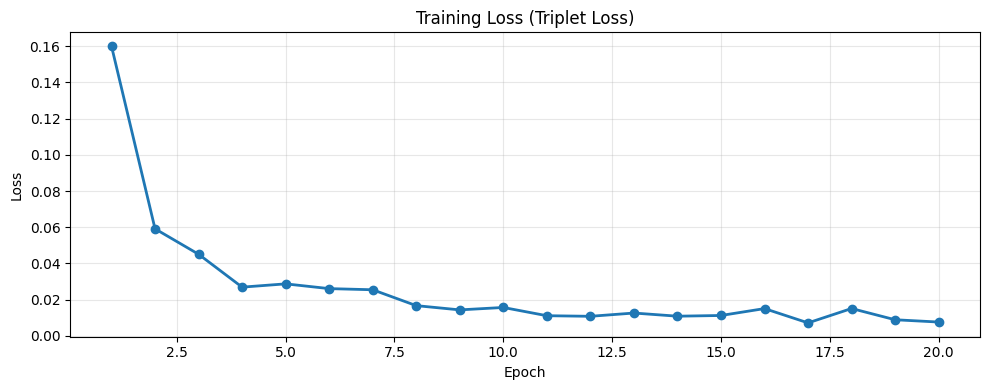

Final best loss: 0.0072
Model saved at : ./face_auth_model.pth


In [9]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', linewidth=2)
plt.title("Training Loss (Triplet Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()
print(f"Final best loss: {best_loss:.4f}")
print(f"Model saved at : {CONFIG['model_save_path']}")

## 10. Determine Optimal Similarity Threshold (on a small validation split)

In [10]:
from sklearn.metrics import roc_auc_score

# Build a simple positive/negative pair validation set
def build_val_pairs(identity_map, n_pairs=500):
    identities = [i for i in identity_map if len(identity_map[i]) >= 2]
    pairs, labels = [], []
    for _ in range(n_pairs // 2):
        # Positive pair
        pid = random.choice(identities)
        a, b = random.sample(identity_map[pid], 2)
        pairs.append((a, b)); labels.append(1)
        # Negative pair
        p1, p2 = random.sample(identities, 2)
        pairs.append((random.choice(identity_map[p1]),
                       random.choice(identity_map[p2])))
        labels.append(0)
    return pairs, labels


val_transform = transforms.Compose([
    transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def get_embedding(model, img_path, device):
    img = val_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
    with torch.no_grad():
        return model(img).squeeze(0)


checkpoint = torch.load(CONFIG["model_save_path"], map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

pairs, labels = build_val_pairs(dataset.identity_map, n_pairs=500)
similarities   = []

for (p1, p2), lbl in tqdm(zip(pairs, labels), total=len(pairs), desc="Validating"):
    e1 = get_embedding(model, p1, DEVICE)
    e2 = get_embedding(model, p2, DEVICE)
    sim = torch.nn.functional.cosine_similarity(e1.unsqueeze(0), e2.unsqueeze(0)).item()
    similarities.append(sim)

auc = roc_auc_score(labels, similarities)
print(f"Validation AUC: {auc:.4f}")

# Find best threshold
from sklearn.metrics import accuracy_score
best_thresh, best_acc = 0.5, 0.0
for t in np.arange(0.3, 0.95, 0.01):
    preds = [1 if s >= t else 0 for s in similarities]
    acc   = accuracy_score(labels, preds)
    if acc > best_acc:
        best_acc, best_thresh = acc, t

print(f"Best threshold : {best_thresh:.2f}")
print(f"Best accuracy  : {best_acc:.4f}")

# Update saved model with threshold
checkpoint["threshold"] = best_thresh
torch.save(checkpoint, CONFIG["model_save_path"])
print(f"Threshold saved to model checkpoint.")

Validating: 100%|██████████| 500/500 [01:19<00:00,  6.27it/s]


Validation AUC: 1.0000
Best threshold : 0.79
Best accuracy  : 0.9980
Threshold saved to model checkpoint.


## 11. Export Summary

In [11]:
ckpt = torch.load(CONFIG["model_save_path"], map_location="cpu")
print("=" * 50)
print("MODEL CHECKPOINT SUMMARY")
print("=" * 50)
print(f"  Saved at  : {CONFIG['model_save_path']}")
print(f"  Epoch     : {ckpt['epoch']}")
print(f"  Best Loss : {ckpt['loss']:.4f}")
print(f"  Threshold : {ckpt.get('threshold', 0.6):.2f}")
print(f"  Backbone  : FaceNet InceptionResnetV1 (InceptionResnetV1 / VGGFace2)")
print(f"  Emb Dim   : {CONFIG['embedding_dim']}")
print("=" * 50)
print("Ready for inference with face_auth_testing.ipynb")

MODEL CHECKPOINT SUMMARY
  Saved at  : ./face_auth_model.pth
  Epoch     : 17
  Best Loss : 0.0072
  Threshold : 0.79
  Backbone  : FaceNet InceptionResnetV1 (InceptionResnetV1 / VGGFace2)
  Emb Dim   : 512
Ready for inference with face_auth_testing.ipynb
